# Cloud and Shadow Cleaning

This notebook demonstrates cleaning a cloud/shadow classification raster using `multiclean.clean_array`.

We load one input, apply edge smoothing and small-island removal, and visualize simple before/after results (including a zoomed view).

## Setup

- `clean_array`: Performs morphological opening (edge smoothing), removes small connected components (islands), and fills gaps using nearest valid class.
- Parameters to tune:
  - `smooth_edge_size` (pixels): Opening kernel size; higher smooths more.
  - `min_island_size` (pixels): Remove components with area less than this threshold.
  - `connectivity`: 4 or 8 for connected component analysis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio as rio
from multiclean import clean_array
from matplotlib.colors import ListedColormap

## Paths

Set the data directory and file paths (provided under `notebooks/data/`).

In [2]:
data_dir = Path().cwd() / "data"

In [3]:
Landsat_cloud_and_cloud_shadow_path = data_dir / "Landsat cloud and cloud shadow.tif"

## Load raster

The raster is a single-band integer class label image.

In [4]:
array = rio.open(Landsat_cloud_and_cloud_shadow_path).read(1)

## Clean raster

Tune parameters for this sample; adjust as needed for your data.

In [5]:
array_cleaned = clean_array(
    array=array,
    smooth_edge_size=3,
    min_island_size=5,
)

## Visualize

Side-by-side original and cleaned with a zoomed-in view. Using `nearest` interpolation for crisp class labels.

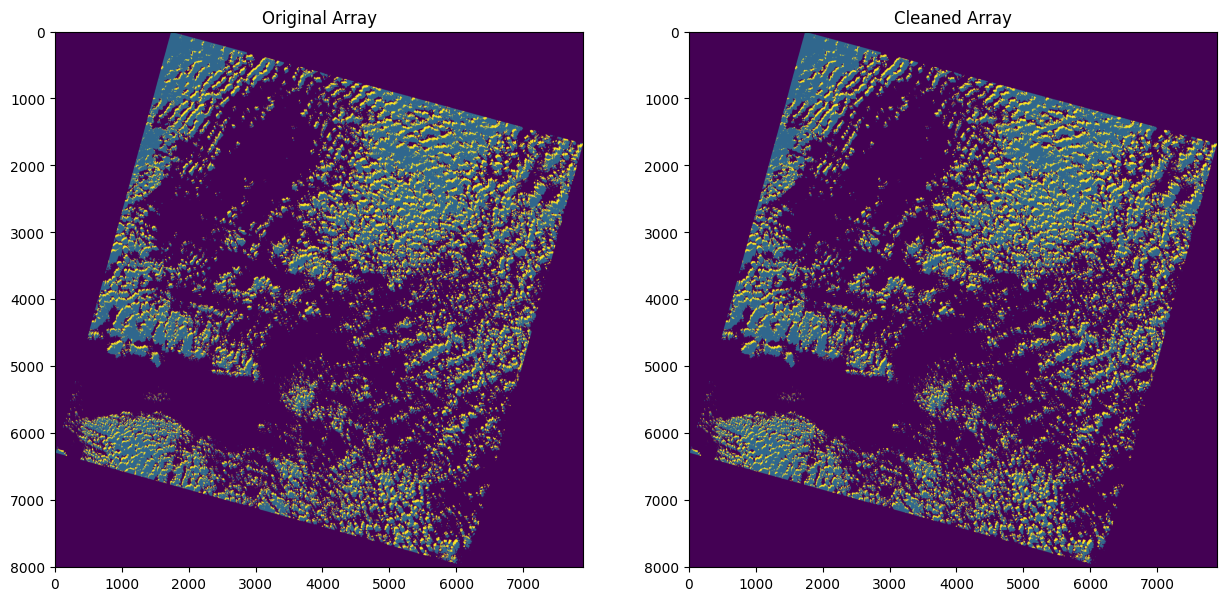

In [6]:
# plot original and cleaned arrays side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
cmap = ListedColormap(plt.get_cmap("viridis")(np.linspace(0, 1, 256)))
im1 = axes[0].imshow(array, cmap=cmap, vmin=0, vmax=3)
axes[0].set_title("Original Array")
im2 = axes[1].imshow(array_cleaned, cmap=cmap, vmin=0, vmax=3)
axes[1].set_title("Cleaned Array")
plt.show()

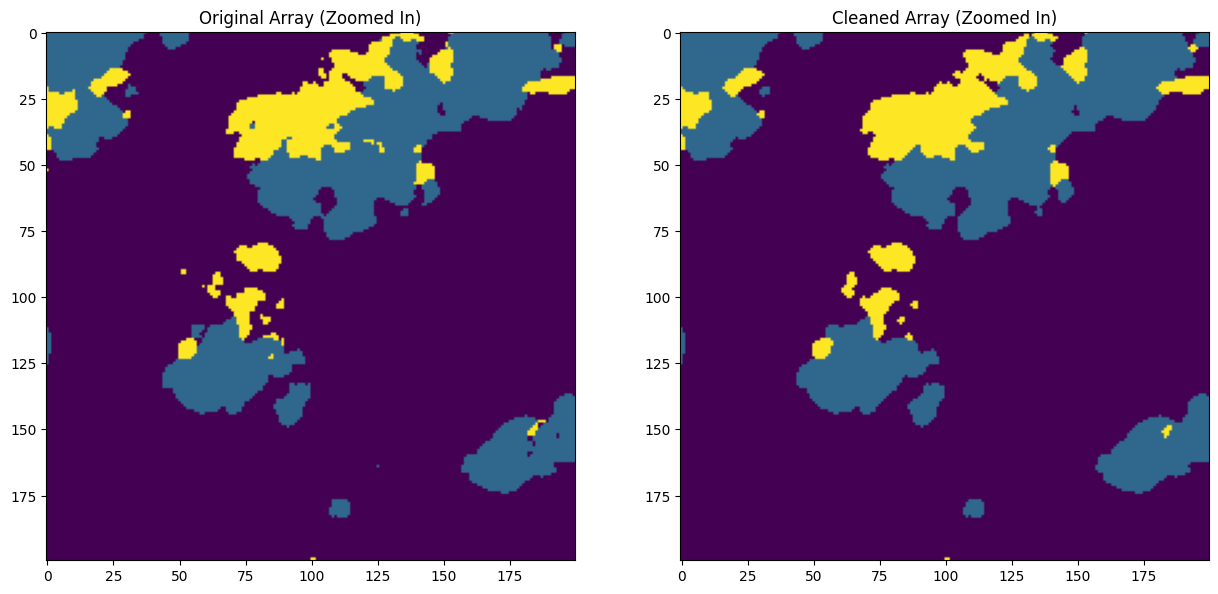

In [7]:
# zoom in to the center of the arrays
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
# yellow to purple
x, y = array.shape[1] // 5, array.shape[0] // 6
zoom_size = 100
im1 = axes[0].imshow(
    array[
        y - zoom_size : y + zoom_size,
        x - zoom_size : x + zoom_size,
    ],
    cmap=cmap,
    vmin=0,
    vmax=3,
)
axes[0].set_title("Original Array (Zoomed In)")
im2 = axes[1].imshow(
    array_cleaned[
        y - zoom_size : y + zoom_size,
        x - zoom_size : x + zoom_size,
    ],
    cmap=cmap,
    vmin=0,
    vmax=3,
)
axes[1].set_title("Cleaned Array (Zoomed In)")
plt.show()